# Notebook 16 — Environment + Behavior Integration and Analysis

## Scientific objective

Integrate session-level environmental metadata from the two accepted sensor JSON files with the accepted TOP behavior-window outputs from Notebook 15, then describe and compare the recorded behavior features between the two observation sessions.

This notebook merges the former sensor-synchronization and environment–behavior-analysis steps. No separate Notebook 17 is created.

## Analysis boundary and scientific limitations

- The JSON files contain only `sensor_at_start` and `sensor_at_end`; they do **not** contain a per-second sensor series.
- Environmental values are therefore session-level context. They are attached to behavior windows by confirmed session mapping, without temporal interpolation or fabricated window-level sensor observations.
- Both sessions have the same recorded temperature and pH. Temperature and pH effects are not testable.
- Light differs between sessions, but there is only one session at each light level. The comparison is descriptive and observational, not causal.
- Behavior windows overlap and are not independent replicates. Tracker IDs and trajectory segments are not biological identities.
- No conclusion is made about stress, sickness, health, happiness, anxiety, aggression, or other latent biological states.

## 1. Provenance and runtime environment

The first executable cell reports the experiment identifier, repository root, interpreter, Conda environment, device, package versions, and current Git commit.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import platform
import subprocess
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPERIMENT_ID = "TOP_ENV_BEHAVIOR_001"
RUN_STARTED_UTC = datetime.now(timezone.utc)
RUN_STARTED_PERF = time.perf_counter()
CONDA_ENV = os.environ.get("CONDA_DEFAULT_ENV", "")
GIT_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=PROJECT_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT_AVAILABLE"

print(f"Experiment ID: {EXPERIMENT_ID}")
print(f"Datetime UTC: {RUN_STARTED_UTC.isoformat()}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python executable: {sys.executable}")
print(f"Python: {platform.python_version()}")
print(f"Conda environment: {CONDA_ENV}")
print(f"Device: {DEVICE}")
print(f"GPU: {GPU_NAME}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"torch: {torch.__version__}")
print(f"Git commit: {GIT_COMMIT}")

Experiment ID: TOP_ENV_BEHAVIOR_001
Datetime UTC: 2026-08-29T09:58:49.499865+00:00
PROJECT_ROOT: /home/diy-hus/fish
Python executable: /home/diy-hus/miniconda3/envs/fish/bin/python
Python: 3.11.15
Conda environment: fish
Device: cuda
GPU: NVIDIA GeForce RTX 3050
pandas: 3.0.5
numpy: 2.1.3
matplotlib: 3.11.1
torch: 2.13.0+cu130
Git commit: cc74ce9c4e7873380a0f88d360817f29b472bcd6


## 2. CONFIG

The session mapping below is user-confirmed. `TOP_VIDEO_2` uses local `2.mp4`, which corresponds to original video `4.mp4` in sensor metadata. Only the six preselected, interpretable Notebook 15 features are analyzed.

In [2]:
SENSOR_FILES = {
    "TOP_VIDEO_1": PROJECT_ROOT / "data/raw/sensors/1.json",
    "TOP_VIDEO_2": PROJECT_ROOT / "data/raw/sensors/2.json",
}
BEHAVIOR_FILES = {
    "individual": PROJECT_ROOT / "outputs/top/behavior/top_individual_window_features.csv",
    "group": PROJECT_ROOT / "outputs/top/behavior/top_group_window_features.csv",
}
ACCEPTED_BEHAVIOR_SHA256 = {
    "individual": "2a6a3396a41de3c5ac78b4a1391aa2c11858a8cfde53633a18bbb1a10cb4faa7",
    "group": "ba5a2687d6c3b998f03a2b060c6084925de83537f186f0e4a7b54fec2d04c893",
}
SCHEMA_PATH = PROJECT_ROOT / "results/behavior/top_behavior_feature_schema.json"
SESSION_EXPECTATIONS = {
    "TOP_VIDEO_1": {
        "source_video": "1.mp4",
        "original_video_name": "1.mp4",
        "session_id": "20260812_130428_T2_1",
        "tank": "T2",
        "scenario": "baseline",
        "temperature": [25.0, 25.0],
        "ph": [6.6, 6.6],
        "light": [203.0, 200.0],
    },
    "TOP_VIDEO_2": {
        "source_video": "2.mp4",
        "original_video_name": "4.mp4",
        "session_id": "20260812_131321_T2_4",
        "tank": "T2",
        "scenario": "baseline",
        "temperature": [25.0, 25.0],
        "ph": [6.6, 6.6],
        "light": [164.0, 165.0],
    },
}
INDIVIDUAL_FEATURES = ["mean_speed_diag_s", "path_efficiency", "mean_abs_turn_rad"]
GROUP_FEATURES = ["mean_nnd_diag", "mean_group_rms_radius_diag", "mean_group_polarization"]
OUTPUT_DIR = PROJECT_ROOT / "outputs/top/environment_behavior"
RESULT_DIR = PROJECT_ROOT / "results/environment"
PLOT_DIR = RESULT_DIR / "plots"
LOG_DIR = PROJECT_ROOT / f"logs/environment/{EXPERIMENT_ID}"
OUTPUT_RELATIVE_PATHS = {
    "individual_integrated": "outputs/top/environment_behavior/top_individual_environment_behavior.csv",
    "group_integrated": "outputs/top/environment_behavior/top_group_environment_behavior.csv",
    "environment_session_summary": "results/environment/environment_session_summary.csv",
    "environment_behavior_summary": "results/environment/environment_behavior_summary.csv",
    "environment_behavior_comparison": "results/environment/environment_behavior_comparison.csv",
}

CONFIG_DISPLAY = {
    "experiment_id": EXPERIMENT_ID,
    "sensor_files": {k: str(v.relative_to(PROJECT_ROOT)) for k, v in SENSOR_FILES.items()},
    "behavior_files": {k: str(v.relative_to(PROJECT_ROOT)) for k, v in BEHAVIOR_FILES.items()},
    "session_mapping": SESSION_EXPECTATIONS,
    "individual_features": INDIVIDUAL_FEATURES,
    "group_features": GROUP_FEATURES,
    "environment_context_level": "session",
    "sensor_interpolation": "none",
    "analysis_type": "descriptive_observational_comparison",
    "output_paths": OUTPUT_RELATIVE_PATHS,
    "plot_dir": str(PLOT_DIR.relative_to(PROJECT_ROOT)),
    "log_dir": str(LOG_DIR.relative_to(PROJECT_ROOT)),
}
print(json.dumps(CONFIG_DISPLAY, indent=2, ensure_ascii=False))

{
  "experiment_id": "TOP_ENV_BEHAVIOR_001",
  "sensor_files": {
    "TOP_VIDEO_1": "data/raw/sensors/1.json",
    "TOP_VIDEO_2": "data/raw/sensors/2.json"
  },
  "behavior_files": {
    "individual": "outputs/top/behavior/top_individual_window_features.csv",
    "group": "outputs/top/behavior/top_group_window_features.csv"
  },
  "session_mapping": {
    "TOP_VIDEO_1": {
      "source_video": "1.mp4",
      "original_video_name": "1.mp4",
      "session_id": "20260812_130428_T2_1",
      "tank": "T2",
      "scenario": "baseline",
      "temperature": [
        25.0,
        25.0
      ],
      "ph": [
        6.6,
        6.6
      ],
      "light": [
        203.0,
        200.0
      ]
    },
    "TOP_VIDEO_2": {
      "source_video": "2.mp4",
      "original_video_name": "4.mp4",
      "session_id": "20260812_131321_T2_4",
      "tank": "T2",
      "scenario": "baseline",
      "temperature": [
        25.0,
        25.0
      ],
      "ph": [
        6.6,
        6.6
      ],
   

## 3. Mandatory input and SHA-256 gate

A behavior-file hash mismatch produces `HOLD`. Notebook 15 is not rerun automatically. Sensor JSONs are read without modification and validated against the confirmed mapping and start/end values.

In [3]:
def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

assert CONDA_ENV == "fish", f"HOLD: select the fish kernel; current Conda environment is {CONDA_ENV!r}"
for required_path in [*SENSOR_FILES.values(), *BEHAVIOR_FILES.values(), SCHEMA_PATH]:
    assert required_path.is_file(), f"HOLD: missing required input {required_path.relative_to(PROJECT_ROOT)}"

behavior_hashes = {name: sha256_file(path) for name, path in BEHAVIOR_FILES.items()}
for name, accepted_hash in ACCEPTED_BEHAVIOR_SHA256.items():
    actual_hash = behavior_hashes[name]
    assert actual_hash == accepted_hash, (
        f"HOLD: {name} behavior SHA-256 mismatch; expected {accepted_hash}, got {actual_hash}. "
        "Do not rerun Notebook 15 automatically."
    )

sensor_docs = {}
sensor_hashes = {}
for video_id, sensor_path in SENSOR_FILES.items():
    with sensor_path.open("r", encoding="utf-8") as handle:
        sensor_doc = json.load(handle)
    expectation = SESSION_EXPECTATIONS[video_id]
    sensor_observation_keys = sorted(key for key in sensor_doc if key.startswith("sensor_at_"))
    assert sensor_observation_keys == ["sensor_at_end", "sensor_at_start"], (
        f"HOLD: unexpected sensor observation structure in {sensor_path.name}: {sensor_observation_keys}"
    )
    assert sensor_doc["session_id"] == expectation["session_id"]
    assert sensor_doc["tank"] == expectation["tank"]
    assert sensor_doc["scenario"] == expectation["scenario"]
    assert Path(sensor_doc["video_path"]).name == expectation["original_video_name"]
    for variable in ["temperature", "ph", "light"]:
        observed_pair = [
            float(sensor_doc["sensor_at_start"][variable]),
            float(sensor_doc["sensor_at_end"][variable]),
        ]
        assert observed_pair == expectation[variable], (
            f"HOLD: {video_id} {variable} mismatch: expected {expectation[variable]}, got {observed_pair}"
        )
    assert pd.Timestamp(sensor_doc["sensor_at_start"]["timestamp"]) <= pd.Timestamp(sensor_doc["sensor_at_end"]["timestamp"])
    sensor_docs[video_id] = sensor_doc
    sensor_hashes[video_id] = sha256_file(sensor_path)

HASH_STATUS = "PASS"
print(f"Hash status: {HASH_STATUS}")
print(json.dumps({"behavior_sha256": behavior_hashes, "sensor_sha256": sensor_hashes}, indent=2))

Hash status: PASS
{
  "behavior_sha256": {
    "individual": "2a6a3396a41de3c5ac78b4a1391aa2c11858a8cfde53633a18bbb1a10cb4faa7",
    "group": "ba5a2687d6c3b998f03a2b060c6084925de83537f186f0e4a7b54fec2d04c893"
  },
  "sensor_sha256": {
    "TOP_VIDEO_1": "5cb582b53710638c60d28347030b1161c0bc71323441a5d821dc7d8c4ac72411",
    "TOP_VIDEO_2": "18dec58ca18fc9a331bf65759a910c80a9ff8c779d1726cd6a7d9c64d4aff523"
  }
}


In [4]:
with SCHEMA_PATH.open("r", encoding="utf-8") as handle:
    feature_schema = json.load(handle)
schema_rows = feature_schema["features"]
schema_lookup = {(row["level"], row["name"]): row for row in schema_rows}

for feature in INDIVIDUAL_FEATURES:
    assert ("individual_window", feature) in schema_lookup, f"HOLD: individual schema field missing: {feature}"
for feature in GROUP_FEATURES:
    assert ("group_window", feature) in schema_lookup, f"HOLD: group schema field missing: {feature}"

individual = pd.read_csv(BEHAVIOR_FILES["individual"])
group = pd.read_csv(BEHAVIOR_FILES["group"])
required_common = {"video_id", "source_video", "window_start_sec", "window_end_sec", "window_mid_sec"}
assert required_common.issubset(individual.columns)
assert required_common.issubset(group.columns)
assert set(INDIVIDUAL_FEATURES).issubset(individual.columns)
assert set(GROUP_FEATURES).issubset(group.columns)
assert set(individual["video_id"].unique()) == set(SESSION_EXPECTATIONS)
assert set(group["video_id"].unique()) == set(SESSION_EXPECTATIONS)
assert np.allclose(individual["window_end_sec"] - individual["window_start_sec"], 5.0)
assert np.allclose(group["window_end_sec"] - group["window_start_sec"], 5.0)
assert not individual.duplicated(["video_id", "trajectory_uid", "window_start_sec", "window_end_sec"]).any()
assert not group.duplicated(["video_id", "window_start_sec", "window_end_sec"]).any()
assert np.isfinite(individual[INDIVIDUAL_FEATURES].to_numpy(dtype=float)).all()
assert np.isfinite(group[GROUP_FEATURES].to_numpy(dtype=float)).all()
for video_id, expectation in SESSION_EXPECTATIONS.items():
    assert set(individual.loc[individual["video_id"] == video_id, "source_video"]) == {expectation["source_video"]}
    assert set(group.loc[group["video_id"] == video_id, "source_video"]) == {expectation["source_video"]}

print(f"Individual windows: {len(individual)}")
print(f"Group windows: {len(group)}")
print("Selected individual features:", INDIVIDUAL_FEATURES)
print("Selected group features:", GROUP_FEATURES)
print("Schema validation: PASS")

Individual windows: 382
Group windows: 167
Selected individual features: ['mean_speed_diag_s', 'path_efficiency', 'mean_abs_turn_rad']
Selected group features: ['mean_nnd_diag', 'mean_group_rms_radius_diag', 'mean_group_polarization']
Schema validation: PASS


## 4. Session-level environmental summary

The mean is the arithmetic mean of the start and end readings. `light_change` is end minus start. No values are generated between the two observations.

In [5]:
environment_rows = []
for video_id, sensor_doc in sensor_docs.items():
    expectation = SESSION_EXPECTATIONS[video_id]
    start = sensor_doc["sensor_at_start"]
    end = sensor_doc["sensor_at_end"]
    environment_rows.append({
        "experiment_id": EXPERIMENT_ID,
        "video_id": video_id,
        "source_video": expectation["source_video"],
        "original_video_name": expectation["original_video_name"],
        "sensor_file": str(SENSOR_FILES[video_id].relative_to(PROJECT_ROOT)),
        "sensor_sha256": sensor_hashes[video_id],
        "session_id": sensor_doc["session_id"],
        "tank": sensor_doc["tank"],
        "scenario": sensor_doc["scenario"],
        "session_start_time": sensor_doc["start_time"],
        "session_end_time": sensor_doc["end_time"],
        "sensor_start_timestamp": start["timestamp"],
        "sensor_end_timestamp": end["timestamp"],
        "temperature_start": float(start["temperature"]),
        "temperature_end": float(end["temperature"]),
        "temperature_mean": (float(start["temperature"]) + float(end["temperature"])) / 2.0,
        "ph_start": float(start["ph"]),
        "ph_end": float(end["ph"]),
        "ph_mean": (float(start["ph"]) + float(end["ph"])) / 2.0,
        "light_start": float(start["light"]),
        "light_end": float(end["light"]),
        "light_mean": (float(start["light"]) + float(end["light"])) / 2.0,
        "light_change": float(end["light"]) - float(start["light"]),
        "environment_context_level": "session",
        "sensor_interpolation": "none",
    })
environment_session_summary = pd.DataFrame(environment_rows).sort_values("video_id").reset_index(drop=True)
assert environment_session_summary["temperature_mean"].nunique() == 1
assert environment_session_summary["ph_mean"].nunique() == 1
assert environment_session_summary["light_mean"].nunique() == 2
display(environment_session_summary[[
    "video_id", "source_video", "original_video_name", "session_id", "tank", "scenario",
    "temperature_mean", "ph_mean", "light_mean", "light_change"
]])

,video_id,source_video,original_video_name,session_id,tank,scenario,temperature_mean,ph_mean,light_mean,light_change
0,TOP_VIDEO_1,1.mp4,1.mp4,20260812_130428_T2_1,T2,baseline,25.0,6.6,201.5,-3.0
1,TOP_VIDEO_2,2.mp4,4.mp4,20260812_131321_T2_4,T2,baseline,25.0,6.6,164.5,1.0


## 5. Attach confirmed session context to behavior windows

The join key is `video_id`. The environmental columns remain explicitly marked as session-level context; they are not time-resolved sensor measurements.

In [6]:
session_metadata_columns = [
    "video_id", "session_id", "tank", "scenario", "temperature_mean", "ph_mean",
    "light_mean", "light_change", "environment_context_level", "sensor_interpolation"
]
session_metadata = environment_session_summary[session_metadata_columns].copy()
individual_integrated = individual.merge(session_metadata, on="video_id", how="left", validate="many_to_one")
group_integrated = group.merge(session_metadata, on="video_id", how="left", validate="many_to_one")

assert len(individual_integrated) == len(individual)
assert len(group_integrated) == len(group)
assert individual_integrated[session_metadata_columns[1:]].notna().all().all()
assert group_integrated[session_metadata_columns[1:]].notna().all().all()
assert set(individual_integrated["environment_context_level"]) == {"session"}
assert set(group_integrated["environment_context_level"]) == {"session"}
assert set(individual_integrated["sensor_interpolation"]) == {"none"}
assert set(group_integrated["sensor_interpolation"]) == {"none"}

print(f"Integrated individual rows: {len(individual_integrated)}")
print(f"Integrated group rows: {len(group_integrated)}")
print("Environment-behavior join: PASS_WITH_WARNING (session-level context only)")

Integrated individual rows: 382
Integrated group rows: 167
Environment-behavior join: PASS_WITH_WARNING (session-level context only)


## 6. Descriptive behavior summaries and between-session comparison

For each selected feature and session, report window count, valid count, mean, standard deviation, median, quartiles, and IQR. Differences are Session 2 minus Session 1. No hypothesis test, p-value, confidence interval, causal estimate, correlation, or regression is computed because there are only two sessions and overlapping windows.

In [7]:
def summarize_features(frame, level, features):
    rows = []
    for video_id, session_frame in frame.groupby("video_id", sort=True):
        context = session_frame.iloc[0]
        for feature in features:
            values = pd.to_numeric(session_frame[feature], errors="coerce").dropna()
            q1 = float(values.quantile(0.25))
            q3 = float(values.quantile(0.75))
            schema_level = "individual_window" if level == "individual" else "group_window"
            rows.append({
                "experiment_id": EXPERIMENT_ID,
                "analysis_type": "descriptive_observational_comparison",
                "level": level,
                "video_id": video_id,
                "source_video": context["source_video"],
                "session_id": context["session_id"],
                "tank": context["tank"],
                "scenario": context["scenario"],
                "n_windows": int(len(session_frame)),
                "feature": feature,
                "unit": schema_lookup[(schema_level, feature)]["unit"],
                "n_valid": int(len(values)),
                "mean": float(values.mean()),
                "std": float(values.std(ddof=1)) if len(values) > 1 else np.nan,
                "median": float(values.median()),
                "q1": q1,
                "q3": q3,
                "iqr": q3 - q1,
                "temperature_mean": float(context["temperature_mean"]),
                "ph_mean": float(context["ph_mean"]),
                "light_mean": float(context["light_mean"]),
                "light_change": float(context["light_change"]),
                "replicate_caution": "Overlapping windows within one session are not independent experimental replicates.",
                "identity_caution": "Tracker ID and trajectory segment are not biological identity.",
            })
    return pd.DataFrame(rows)

individual_summary = summarize_features(individual_integrated, "individual", INDIVIDUAL_FEATURES)
group_summary = summarize_features(group_integrated, "group", GROUP_FEATURES)
feature_summary_long = pd.concat([individual_summary, group_summary], ignore_index=True)
assert len(feature_summary_long) == 12

summary_wide_rows = []
for video_id in SESSION_EXPECTATIONS:
    env_row = environment_session_summary.loc[environment_session_summary["video_id"] == video_id].iloc[0]
    row = {
        "experiment_id": EXPERIMENT_ID,
        "analysis_type": "descriptive_observational_comparison",
        "video_id": video_id,
        "source_video": env_row["source_video"],
        "session_id": env_row["session_id"],
        "tank": env_row["tank"],
        "scenario": env_row["scenario"],
        "n_individual_windows": int((individual_integrated["video_id"] == video_id).sum()),
        "n_group_windows": int((group_integrated["video_id"] == video_id).sum()),
        "temperature_mean": float(env_row["temperature_mean"]),
        "ph_mean": float(env_row["ph_mean"]),
        "light_mean": float(env_row["light_mean"]),
        "light_change": float(env_row["light_change"]),
    }
    for _, feature_row in feature_summary_long.loc[feature_summary_long["video_id"] == video_id].iterrows():
        feature = feature_row["feature"]
        for statistic in ["mean", "std", "median", "q1", "q3", "iqr"]:
            row[f"{feature}_{statistic}"] = feature_row[statistic]
    summary_wide_rows.append(row)
environment_behavior_summary = pd.DataFrame(summary_wide_rows)
assert len(environment_behavior_summary) == 2

session_1 = feature_summary_long[feature_summary_long["video_id"] == "TOP_VIDEO_1"].copy()
session_2 = feature_summary_long[feature_summary_long["video_id"] == "TOP_VIDEO_2"].copy()
comparison = session_1.merge(session_2, on=["level", "feature", "unit"], suffixes=("_session1", "_session2"), validate="one_to_one")
environment_behavior_comparison = pd.DataFrame({
    "experiment_id": EXPERIMENT_ID,
    "analysis_type": "descriptive_observational_comparison",
    "level": comparison["level"],
    "feature": comparison["feature"],
    "unit": comparison["unit"],
    "session1_id": comparison["session_id_session1"],
    "session1_n_windows": comparison["n_windows_session1"],
    "session1_mean": comparison["mean_session1"],
    "session1_median": comparison["median_session1"],
    "session1_iqr": comparison["iqr_session1"],
    "session1_temperature_mean": comparison["temperature_mean_session1"],
    "session1_ph_mean": comparison["ph_mean_session1"],
    "session1_light_mean": comparison["light_mean_session1"],
    "session2_id": comparison["session_id_session2"],
    "session2_n_windows": comparison["n_windows_session2"],
    "session2_mean": comparison["mean_session2"],
    "session2_median": comparison["median_session2"],
    "session2_iqr": comparison["iqr_session2"],
    "session2_temperature_mean": comparison["temperature_mean_session2"],
    "session2_ph_mean": comparison["ph_mean_session2"],
    "session2_light_mean": comparison["light_mean_session2"],
    "mean_difference_session2_minus_session1": comparison["mean_session2"] - comparison["mean_session1"],
    "median_difference_session2_minus_session1": comparison["median_session2"] - comparison["median_session1"],
    "causal_inference": "NOT_SUPPORTED",
    "interpretation": "Recorded behavior differs descriptively between two sessions; session and light condition are confounded.",
})
assert len(environment_behavior_comparison) == 6
display(feature_summary_long[["level", "video_id", "n_windows", "feature", "mean", "median", "iqr", "std", "light_mean"]])
display(environment_behavior_summary)
display(environment_behavior_comparison[["level", "feature", "mean_difference_session2_minus_session1", "median_difference_session2_minus_session1", "causal_inference"]])

,level,video_id,n_windows,feature,mean,median,iqr,std,light_mean
0,individual,TOP_VIDEO_1,82,mean_speed_diag_s,0.029941,0.018273,0.027590,0.027737,201.5
1,individual,TOP_VIDEO_1,82,path_efficiency,0.530419,0.510007,0.367320,0.234529,201.5
2,individual,TOP_VIDEO_1,82,mean_abs_turn_rad,0.658478,0.687178,0.394747,0.255824,201.5
3,individual,TOP_VIDEO_2,300,mean_speed_diag_s,0.030752,0.025104,0.026491,0.023195,164.5
4,individual,TOP_VIDEO_2,300,path_efficiency,0.498237,0.483203,0.404151,0.230679,164.5
5,individual,TOP_VIDEO_2,300,mean_abs_turn_rad,0.545217,0.502675,0.256744,0.210960,164.5
6,group,TOP_VIDEO_1,53,mean_nnd_diag,0.193581,0.188686,0.092510,0.052601,201.5
7,group,TOP_VIDEO_1,53,mean_group_rms_radius_diag,0.089814,0.091444,0.028191,0.027909,201.5
8,group,TOP_VIDEO_1,53,mean_group_polarization,0.591554,0.591241,0.111536,0.096190,201.5
9,group,TOP_VIDEO_2,114,mean_nnd_diag,0.221302,0.204448,0.117975,0.084828,164.5


,experiment_id,analysis_type,video_id,source_video,session_id,tank,scenario,n_individual_windows,n_group_windows,temperature_mean,...,mean_group_rms_radius_diag_median,mean_group_rms_radius_diag_q1,mean_group_rms_radius_diag_q3,mean_group_rms_radius_diag_iqr,mean_group_polarization_mean,mean_group_polarization_std,mean_group_polarization_median,mean_group_polarization_q1,mean_group_polarization_q3,mean_group_polarization_iqr
0,TOP_ENV_BEHAVIOR_001,descriptive_observational_comparison,TOP_VIDEO_1,1.mp4,20260812_130428_T2_1,T2,baseline,82,53,25.0,...,0.091444,0.078560,0.106751,0.028191,0.591554,0.096190,0.591241,0.538572,0.650108,0.111536
1,TOP_ENV_BEHAVIOR_001,descriptive_observational_comparison,TOP_VIDEO_2,2.mp4,20260812_131321_T2_4,T2,baseline,300,114,25.0,...,0.164265,0.144963,0.180077,0.035114,0.550836,0.075386,0.538712,0.499909,0.586916,0.087007


,level,feature,mean_difference_session2_minus_session1,median_difference_session2_minus_session1,causal_inference
0,individual,mean_speed_diag_s,0.000810,0.006831,NOT_SUPPORTED
1,individual,path_efficiency,-0.032182,-0.026804,NOT_SUPPORTED
2,individual,mean_abs_turn_rad,-0.113262,-0.184503,NOT_SUPPORTED
3,group,mean_nnd_diag,0.027721,0.015763,NOT_SUPPORTED
4,group,mean_group_rms_radius_diag,0.072229,0.072822,NOT_SUPPORTED
5,group,mean_group_polarization,-0.040718,-0.052529,NOT_SUPPORTED


## 7. Biểu đồ kết quả

Các biểu đồ thể hiện phân bố mô tả theo cửa sổ; không đại diện cho mẫu lặp sinh học độc lập hay tác động nhân quả.

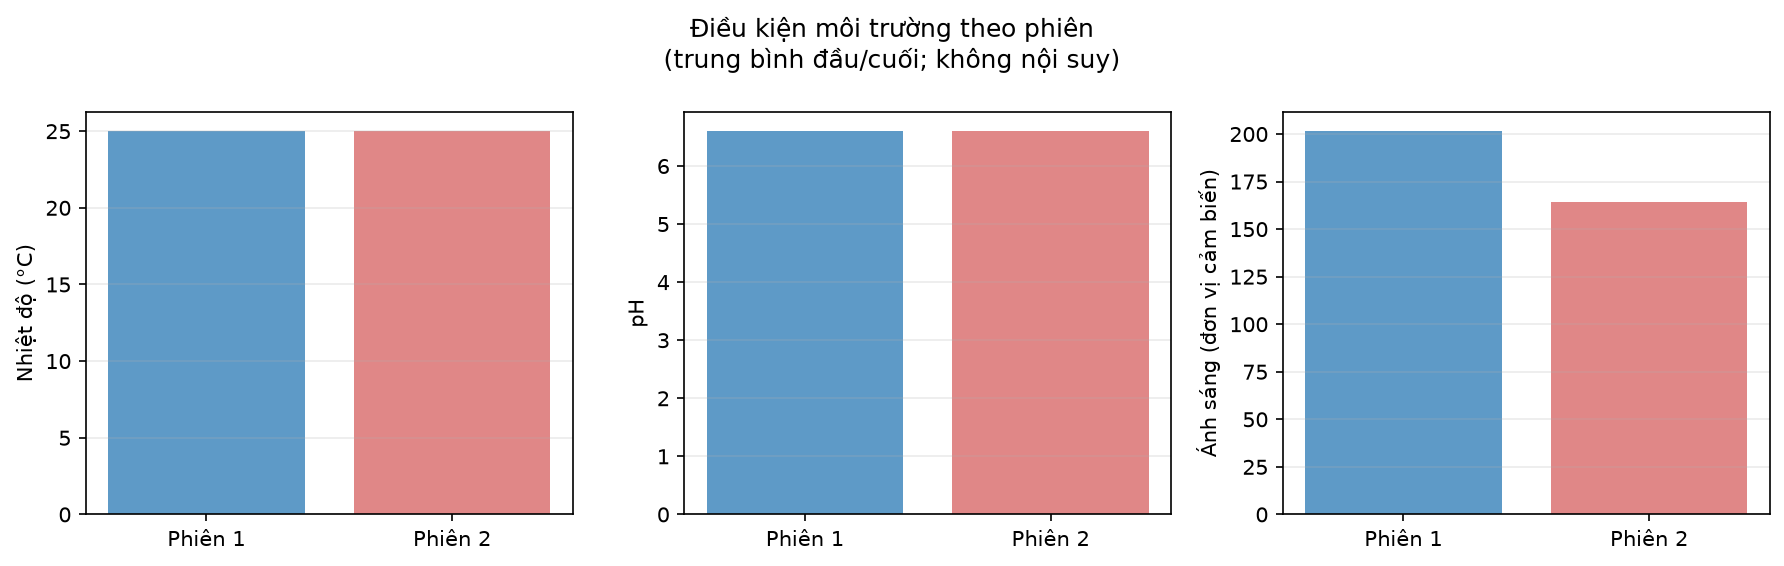

Created: results/environment/plots/top_environment_session_conditions.png | bytes=49785


In [8]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.family": "DejaVu Sans", "axes.unicode_minus": False})
SESSION_ORDER = ["TOP_VIDEO_1", "TOP_VIDEO_2"]
SESSION_LABELS = ["Phiên 1", "Phiên 2"]
SESSION_COLORS = ["#2878B5", "#D65F5F"]
plot_paths = []
runtime_warnings = []

def save_figure(fig, filename):
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    plot_paths.append(path)
    print(f"Created: {path.relative_to(PROJECT_ROOT)} | bytes={path.stat().st_size}")

def session_values(frame, feature):
    return [pd.to_numeric(frame.loc[frame["video_id"] == video_id, feature], errors="coerce").dropna().to_numpy() for video_id in SESSION_ORDER]

def boxplot_feature(ax, frame, feature, ylabel, title):
    values = session_values(frame, feature)
    artists = ax.boxplot(values, tick_labels=SESSION_LABELS, patch_artist=True, showfliers=True)
    for patch, color in zip(artists["boxes"], SESSION_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, column, label in zip(axes, ["temperature_mean", "ph_mean", "light_mean"], ["Nhiệt độ (°C)", "pH", "Ánh sáng (đơn vị cảm biến)"]):
    values = environment_session_summary.set_index("video_id").loc[SESSION_ORDER, column].to_numpy()
    ax.bar(SESSION_LABELS, values, color=SESSION_COLORS, alpha=0.75)
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Điều kiện môi trường theo phiên\n(trung bình đầu/cuối; không nội suy)")
fig.tight_layout()
save_figure(fig, "top_environment_session_conditions.png")

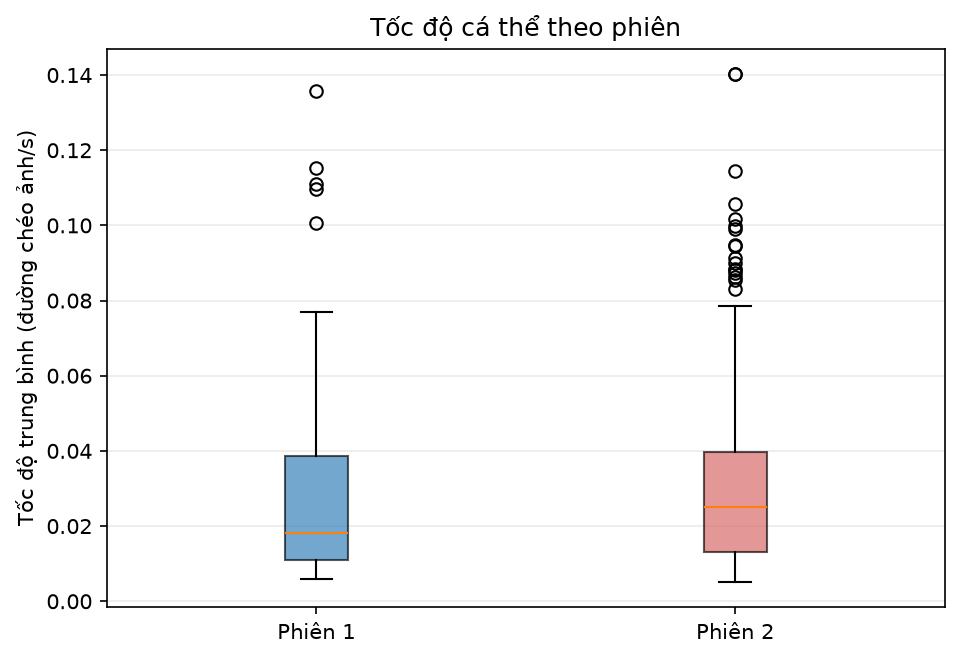

Created: results/environment/plots/top_individual_speed_comparison.png | bytes=35382


In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
boxplot_feature(ax, individual_integrated, "mean_speed_diag_s", "Tốc độ trung bình (đường chéo ảnh/s)", "Tốc độ cá thể theo phiên")
fig.tight_layout()
save_figure(fig, "top_individual_speed_comparison.png")

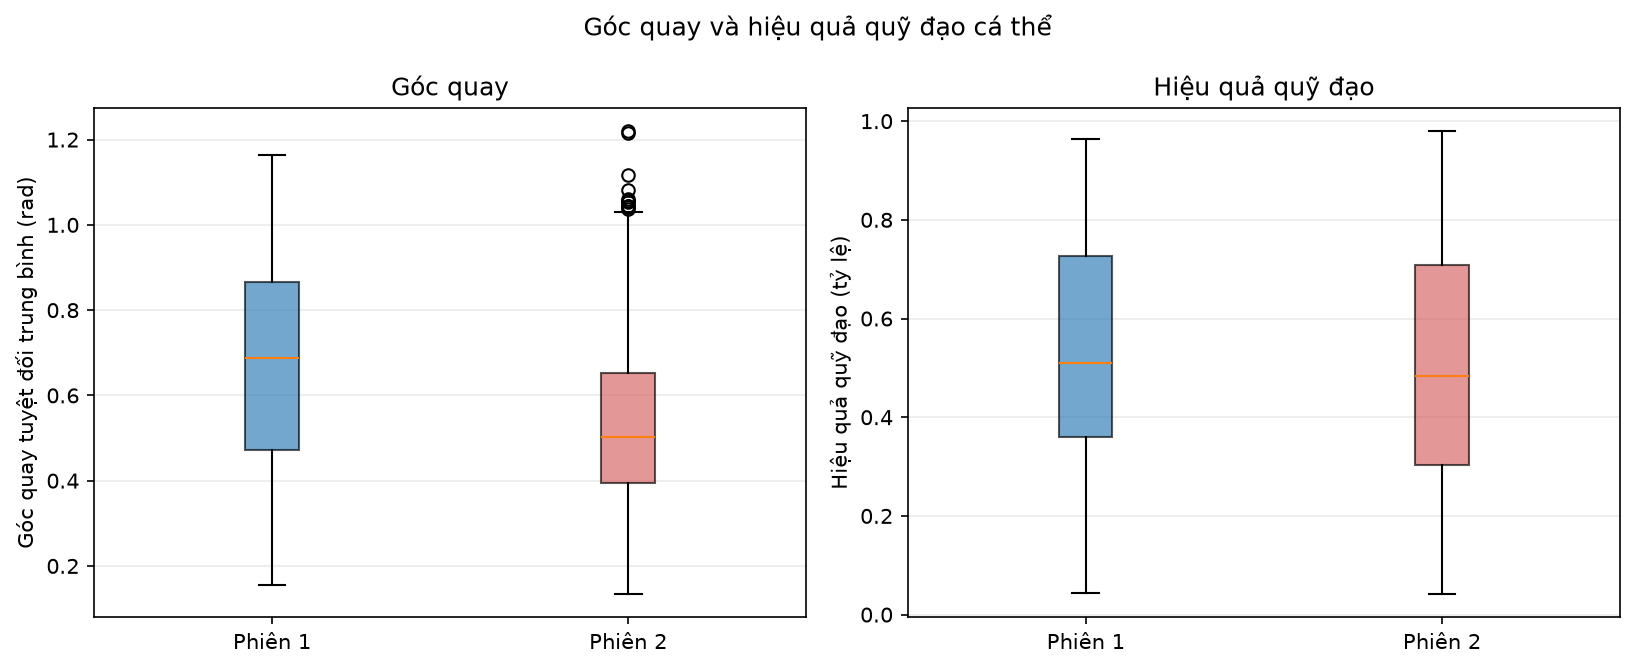

Created: results/environment/plots/top_individual_turning_path_efficiency.png | bytes=56146


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
boxplot_feature(axes[0], individual_integrated, "mean_abs_turn_rad", "Góc quay tuyệt đối trung bình (rad)", "Góc quay")
boxplot_feature(axes[1], individual_integrated, "path_efficiency", "Hiệu quả quỹ đạo (tỷ lệ)", "Hiệu quả quỹ đạo")
fig.suptitle("Góc quay và hiệu quả quỹ đạo cá thể")
fig.tight_layout()
save_figure(fig, "top_individual_turning_path_efficiency.png")

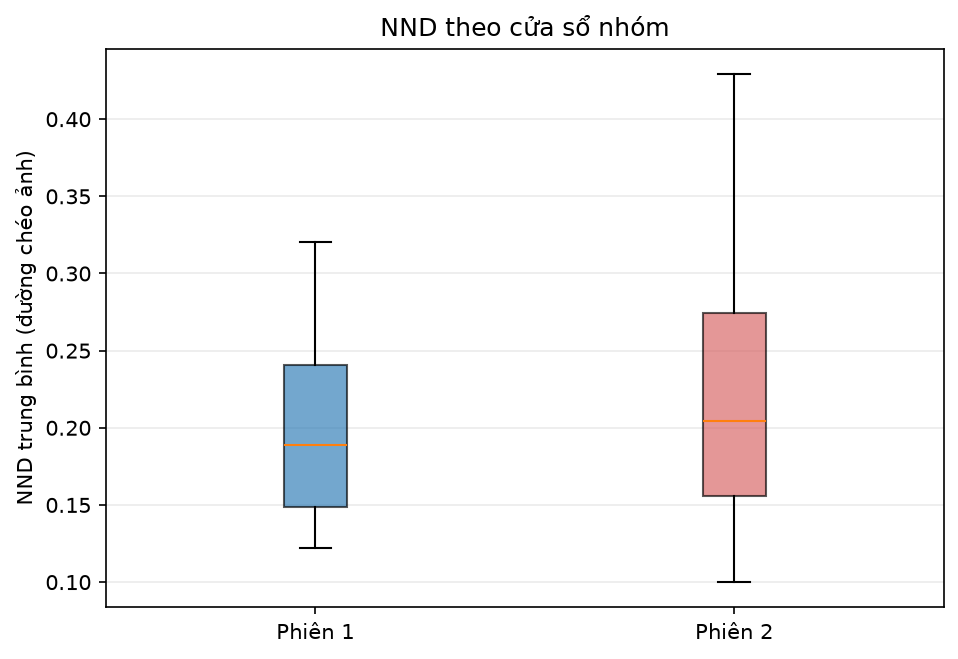

Created: results/environment/plots/top_group_nearest_neighbor_comparison.png | bytes=28616


In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
boxplot_feature(ax, group_integrated, "mean_nnd_diag", "NND trung bình (đường chéo ảnh)", "NND theo cửa sổ nhóm")
fig.tight_layout()
save_figure(fig, "top_group_nearest_neighbor_comparison.png")

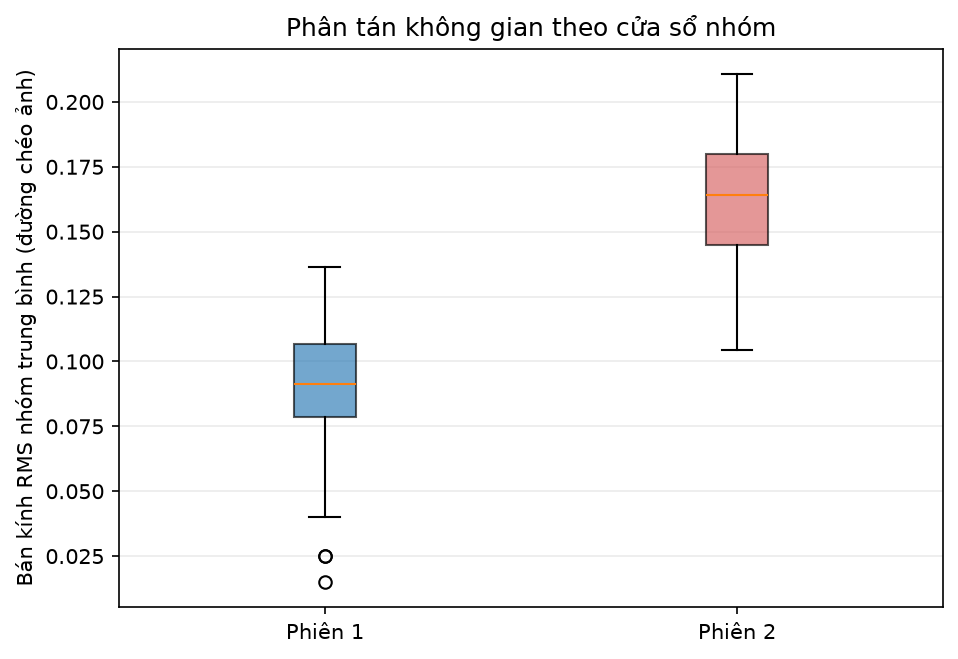

Created: results/environment/plots/top_group_dispersion_comparison.png | bytes=35472


In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
boxplot_feature(ax, group_integrated, "mean_group_rms_radius_diag", "Bán kính RMS nhóm trung bình (đường chéo ảnh)", "Phân tán không gian theo cửa sổ nhóm")
fig.tight_layout()
save_figure(fig, "top_group_dispersion_comparison.png")

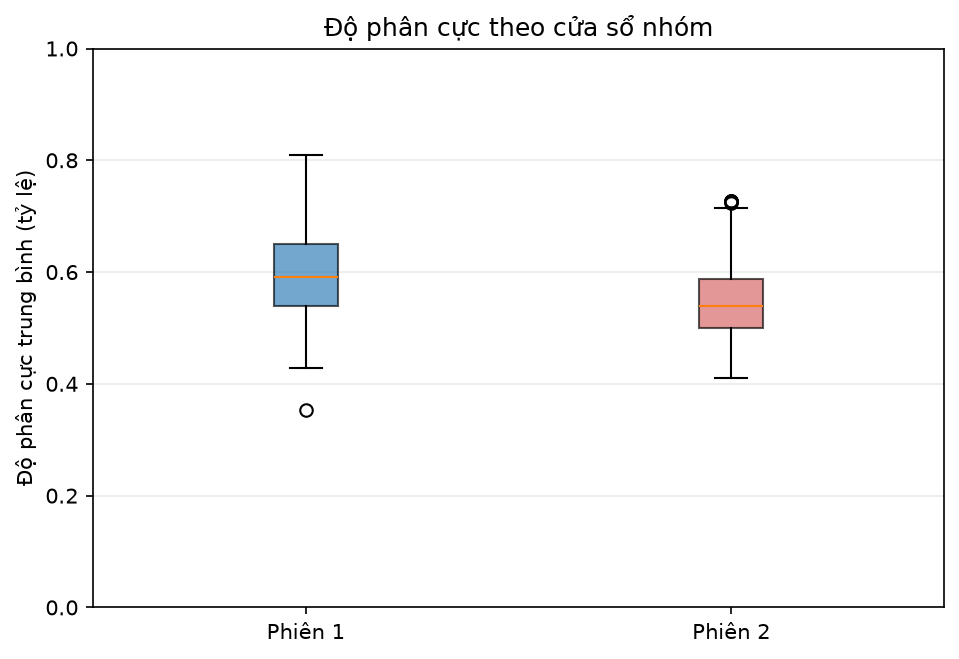

Created: results/environment/plots/top_group_polarization_comparison.png | bytes=26970


In [13]:
polarization_values = session_values(group_integrated, "mean_group_polarization")
if all(len(values) > 0 for values in polarization_values):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    boxplot_feature(ax, group_integrated, "mean_group_polarization", "Độ phân cực trung bình (tỷ lệ)", "Độ phân cực theo cửa sổ nhóm")
    ax.set_ylim(0.0, 1.0)
    fig.tight_layout()
    save_figure(fig, "top_group_polarization_comparison.png")
else:
    warning = "Polarization plot skipped because at least one session has no valid polarization window."
    runtime_warnings.append(warning)
    print(f"WARNING: {warning}")

## 8. Save local integrated outputs and commit-sized evidence

Full integrated tables remain under ignored `outputs/`. Small summaries, plots, and provenance logs are written under `results/` and `logs/`.

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

output_paths = {name: PROJECT_ROOT / relative_path for name, relative_path in OUTPUT_RELATIVE_PATHS.items()}
individual_integrated.to_csv(output_paths["individual_integrated"], index=False)
group_integrated.to_csv(output_paths["group_integrated"], index=False)
environment_session_summary.to_csv(output_paths["environment_session_summary"], index=False)
environment_behavior_summary.to_csv(output_paths["environment_behavior_summary"], index=False)
environment_behavior_comparison.to_csv(output_paths["environment_behavior_comparison"], index=False)

DECISIONS = {
    "environmental_metadata": "PASS",
    "environment_behavior_integration": "PASS_WITH_WARNING",
    "behavior_comparison": "PASS_WITH_WARNING",
    "causal_inference": "NOT_SUPPORTED",
    "temperature_effect": "NOT_TESTABLE",
    "ph_effect": "NOT_TESTABLE",
    "light_condition_comparison": "DESCRIPTIVE_ONLY",
    "notebook_16": "PASS_WITH_WARNING",
    "research_analysis_ready": "YES",
}
SCIENTIFIC_WARNINGS = [
    "Sensor data contain only start and end readings; environment is session-level context and is not interpolated.",
    "Temperature and pH are equal across the two sessions, so their effects are not testable.",
    "There is one session at each recorded light level; light condition is confounded with session and causal inference is unsupported.",
    "Behavior windows overlap and are not independent experimental replicates.",
    "Tracker IDs and trajectory segments are not biological identities.",
    "Group descriptors use observed tracker rows; active tracks are not a verified fish count.",
    "No latent biological state such as stress, sickness, health, happiness, anxiety, or aggression is inferred.",
] + runtime_warnings

config_path = LOG_DIR / "config.yaml"
environment_path = LOG_DIR / "environment.txt"
summary_path = LOG_DIR / "summary.json"
config_lines = [
    f"experiment_id: {EXPERIMENT_ID}",
    "analysis_type: descriptive_observational_comparison",
    "environment_context_level: session",
    "sensor_interpolation: none",
    "sensor_files:",
]
for video_id, path in SENSOR_FILES.items():
    config_lines.append(f"  {video_id}: {path.relative_to(PROJECT_ROOT)}")
config_lines.extend([
    f"individual_behavior_file: {BEHAVIOR_FILES['individual'].relative_to(PROJECT_ROOT)}",
    f"group_behavior_file: {BEHAVIOR_FILES['group'].relative_to(PROJECT_ROOT)}",
    "accepted_behavior_sha256:",
    f"  individual: {ACCEPTED_BEHAVIOR_SHA256['individual']}",
    f"  group: {ACCEPTED_BEHAVIOR_SHA256['group']}",
    "session_mapping:",
])
for video_id, expectation in SESSION_EXPECTATIONS.items():
    config_lines.extend([
        f"  {video_id}:",
        f"    local_video: {expectation['source_video']}",
        f"    original_video: {expectation['original_video_name']}",
        f"    session_id: {expectation['session_id']}",
        f"    tank: {expectation['tank']}",
        f"    scenario: {expectation['scenario']}",
    ])
config_lines.extend([
    "individual_features:",
])
config_lines.extend(f"  - {feature}" for feature in INDIVIDUAL_FEATURES)
config_lines.append("group_features:")
config_lines.extend(f"  - {feature}" for feature in GROUP_FEATURES)
config_path.write_text("\n".join(config_lines) + "\n", encoding="utf-8")

environment_lines = [
    f"datetime_utc={RUN_STARTED_UTC.isoformat()}",
    f"git_commit={GIT_COMMIT}",
    f"python_executable={sys.executable}",
    f"python={platform.python_version()}",
    f"conda_env={CONDA_ENV}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"matplotlib={matplotlib.__version__}",
    f"torch={torch.__version__}",
    f"cuda_available={torch.cuda.is_available()}",
    f"gpu={GPU_NAME}",
]
environment_path.write_text("\n".join(environment_lines) + "\n", encoding="utf-8")

output_hashes = {name: sha256_file(path) for name, path in output_paths.items()}
plot_hashes = {path.name: sha256_file(path) for path in plot_paths}
runtime_sec = time.perf_counter() - RUN_STARTED_PERF
summary_payload = {
    "experiment_id": EXPERIMENT_ID,
    "datetime_utc": RUN_STARTED_UTC.isoformat(),
    "git_commit": GIT_COMMIT,
    "input_sensor_paths": {k: str(v.relative_to(PROJECT_ROOT)) for k, v in SENSOR_FILES.items()},
    "input_sensor_sha256": sensor_hashes,
    "input_behavior_paths": {k: str(v.relative_to(PROJECT_ROOT)) for k, v in BEHAVIOR_FILES.items()},
    "input_behavior_sha256": behavior_hashes,
    "session_mapping": SESSION_EXPECTATIONS,
    "selected_features": {"individual": INDIVIDUAL_FEATURES, "group": GROUP_FEATURES},
    "environment_context_level": "session",
    "sensor_interpolation": "none",
    "row_counts": {
        "environment_sessions": int(len(environment_session_summary)),
        "individual_integrated_windows": int(len(individual_integrated)),
        "group_integrated_windows": int(len(group_integrated)),
        "summary_rows": int(len(environment_behavior_summary)),
        "comparison_rows": int(len(environment_behavior_comparison)),
    },
    "output_paths": {name: str(path.relative_to(PROJECT_ROOT)) for name, path in output_paths.items()},
    "output_sha256": output_hashes,
    "plot_paths": [str(path.relative_to(PROJECT_ROOT)) for path in plot_paths],
    "plot_sha256": plot_hashes,
    "runtime_sec": runtime_sec,
    "warnings": SCIENTIFIC_WARNINGS,
    "decisions": DECISIONS,
    "next_step": "STOP for user post-run audit; do not create Notebook 17.",
}
summary_path.write_text(json.dumps(summary_payload, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

for name, path in output_paths.items():
    rows = len(pd.read_csv(path))
    print(f"Created: {path.relative_to(PROJECT_ROOT)} | rows={rows} | bytes={path.stat().st_size}")
for path in [config_path, environment_path, summary_path]:
    print(f"Created: {path.relative_to(PROJECT_ROOT)} | bytes={path.stat().st_size}")

Created: outputs/top/environment_behavior/top_individual_environment_behavior.csv | rows=382 | bytes=372329
Created: outputs/top/environment_behavior/top_group_environment_behavior.csv | rows=167 | bytes=72950
Created: results/environment/environment_session_summary.csv | rows=2 | bytes=990
Created: results/environment/environment_behavior_summary.csv | rows=2 | bytes=2690
Created: results/environment/environment_behavior_comparison.csv | rows=6 | bytes=3134
Created: logs/environment/TOP_ENV_BEHAVIOR_001/config.yaml | bytes=1044
Created: logs/environment/TOP_ENV_BEHAVIOR_001/environment.txt | bytes=302
Created: logs/environment/TOP_ENV_BEHAVIOR_001/summary.json | bytes=5558


## 9. Final decision

The decision explicitly separates valid metadata integration and descriptive comparison from unsupported causal inference.

In [16]:
assert all(path.is_file() and path.stat().st_size > 0 for path in output_paths.values())
assert all(path.is_file() and path.stat().st_size > 0 for path in plot_paths)
assert config_path.is_file() and environment_path.is_file() and summary_path.is_file()

print("FINAL SUMMARY")
print(f"Environmental metadata: {DECISIONS['environmental_metadata']}")
print(f"Environment-behavior integration: {DECISIONS['environment_behavior_integration']}")
print(f"Behavior comparison: {DECISIONS['behavior_comparison']}")
print(f"Causal inference: {DECISIONS['causal_inference']}")
print(f"Temperature effect: {DECISIONS['temperature_effect']}")
print(f"pH effect: {DECISIONS['ph_effect']}")
print(f"Light condition comparison: {DECISIONS['light_condition_comparison']}")
print(f"Notebook 16: {DECISIONS['notebook_16']}")
print(f"Research analysis ready: {DECISIONS['research_analysis_ready']}")
print(f"Runtime: {runtime_sec:.3f} s")
print("Warnings:")
for warning in SCIENTIFIC_WARNINGS:
    print(f"- {warning}")
print("Output files:")
for path in [*output_paths.values(), *plot_paths, config_path, environment_path, summary_path]:
    print(f"- {path.relative_to(PROJECT_ROOT)}")
print("Next step: STOP for user post-run audit. Notebook 17 is merged and must not be created.")

FINAL SUMMARY
Environmental metadata: PASS
Environment-behavior integration: PASS_WITH_WARNING
Behavior comparison: PASS_WITH_WARNING
Causal inference: NOT_SUPPORTED
Temperature effect: NOT_TESTABLE
pH effect: NOT_TESTABLE
Light condition comparison: DESCRIPTIVE_ONLY
Notebook 16: PASS_WITH_WARNING
Research analysis ready: YES
Runtime: 1.769 s
Warnings:
- Sensor data contain only start and end readings; environment is session-level context and is not interpolated.
- Temperature and pH are equal across the two sessions, so their effects are not testable.
- There is one session at each recorded light level; light condition is confounded with session and causal inference is unsupported.
- Behavior windows overlap and are not independent experimental replicates.
- Tracker IDs and trajectory segments are not biological identities.
- Group descriptors use observed tracker rows; active tracks are not a verified fish count.
- No latent biological state such as stress, sickness, health, happines